In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Locate the project root whether the notebook starts
# from the project folder or the notebooks folder
current_folder = Path.cwd()
project_root = (
    current_folder.parent
    if current_folder.name == "notebooks"
    else current_folder
)

# Build the path to the selected diabetes dataset
data_path = (
    project_root
    / "data"
    / "raw"
    / "diabetes_binary_health_indicators_BRFSS2015.csv"
)

# Verify the dataset path before reading the file
print("Dataset path:", data_path)
print("File exists:", data_path.exists())

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(data_path)

# Display the dataset dimensions and first five records
print("Dataset shape:", df.shape)
display(df.head())

Dataset path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\raw\diabetes_binary_health_indicators_BRFSS2015.csv
File exists: True
Dataset shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
# Display all column names
print("Column names:")
print(df.columns.tolist())

# Display column data types
print("\nData types:")
print(df.dtypes)

# Count missing values in each column
missing_values = df.isnull().sum()
print("\nTotal missing values:", missing_values.sum())

if missing_values.sum() > 0:
    display(
        missing_values[missing_values > 0]
        .sort_values(ascending=False)
        .to_frame("Missing Values")
    )
else:
    print("No explicit missing values were found.")

# Count completely duplicated rows
duplicate_rows = df.duplicated().sum()
print("\nDuplicated rows:", duplicate_rows)

# Calculate the target class distribution
target_counts = df["Diabetes_binary"].value_counts().sort_index()
target_percentages = (
    df["Diabetes_binary"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

print("\nTarget class distribution:")
display(target_distribution)

Column names:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Data types:
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income               

,Count,Percentage
Diabetes_binary,,
0.0,218334,86.07
1.0,35346,13.93


In [6]:
# Print the target distribution as plain text
print(target_distribution.to_string())

                  Count  Percentage
Diabetes_binary                    
0.0              218334       86.07
1.0               35346       13.93


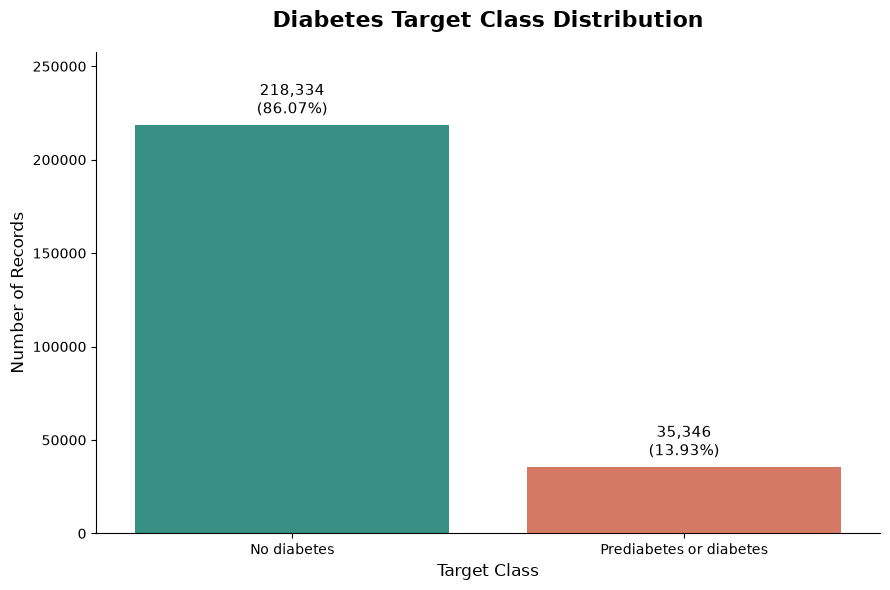

Chart saved to: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\diabetes_target_distribution.png


In [7]:
# Create readable labels for the target classes
class_labels = {
    0.0: "No diabetes",
    1.0: "Prediabetes or diabetes"
}

plot_data = df["Diabetes_binary"].map(class_labels)

# Create the target class distribution chart
fig, ax = plt.subplots(figsize=(9, 6))

sns.countplot(
    x=plot_data,
    hue=plot_data,
    palette=["#2A9D8F", "#E76F51"],
    legend=False,
    ax=ax
)

# Add extra space above the bars for the labels
maximum_count = df["Diabetes_binary"].value_counts().max()
ax.set_ylim(0, maximum_count * 1.18)

# Add count and percentage labels above each bar
total_records = len(df)

for container in ax.containers:
    labels = [
        f"{int(bar.get_height()):,}\n"
        f"({bar.get_height() / total_records * 100:.2f}%)"
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=5,
        fontsize=11
    )

ax.set_title(
    "Diabetes Target Class Distribution",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Target Class", fontsize=12)
ax.set_ylabel("Number of Records", fontsize=12)

sns.despine()
plt.tight_layout()

# Save the corrected chart for the final report
figures_folder = project_root / "reports" / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)

figure_path = figures_folder / "diabetes_target_distribution.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:", figure_path)

In [11]:
# Define columns that should contain only binary values
binary_columns = [
    "Diabetes_binary",
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

# Define the expected ranges for numerical and ordinal columns
expected_ranges = {
    "BMI": (1, 100),
    "GenHlth": (1, 5),
    "MentHlth": (0, 30),
    "PhysHlth": (0, 30),
    "Age": (1, 13),
    "Education": (1, 6),
    "Income": (1, 8)
}

# Build a summary table for every column
feature_summary = pd.DataFrame({
    "Minimum": df.min(),
    "Maximum": df.max(),
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

display(feature_summary)

# Validate all binary columns
invalid_binary_values = {}

for column in binary_columns:
    invalid_values = sorted(
        set(df[column].unique()) - {0.0, 1.0}
    )

    if invalid_values:
        invalid_binary_values[column] = invalid_values

# Validate numerical and ordinal ranges
invalid_range_columns = {}

for column, (minimum, maximum) in expected_ranges.items():
    invalid_count = (
        (df[column] < minimum) |
        (df[column] > maximum)
    ).sum()

    if invalid_count > 0:
        invalid_range_columns[column] = int(invalid_count)

print("Invalid binary columns:", invalid_binary_values)
print("Columns with values outside expected ranges:", invalid_range_columns)

,Minimum,Maximum,Unique Values,Missing Values
Diabetes_binary,0.0,1.0,2,0
HighBP,0.0,1.0,2,0
HighChol,0.0,1.0,2,0
CholCheck,0.0,1.0,2,0
BMI,12.0,98.0,84,0
Smoker,0.0,1.0,2,0
Stroke,0.0,1.0,2,0
HeartDiseaseorAttack,0.0,1.0,2,0
PhysActivity,0.0,1.0,2,0
Fruits,0.0,1.0,2,0


Invalid binary columns: {}
Columns with values outside expected ranges: {}


In [12]:
# Create a separate cleaned copy of the original dataset
df_clean = df.copy()

# Keep BMI as a continuous numerical feature
df_clean["BMI"] = df_clean["BMI"].astype("float32")

# Convert all encoded categorical and ordinal columns to integers
integer_columns = [
    column
    for column in df_clean.columns
    if column != "BMI"
]

df_clean[integer_columns] = (
    df_clean[integer_columns]
    .astype("int8")
)

# Verify that cleaning did not change the number of records
assert df_clean.shape == df.shape
assert df_clean.isnull().sum().sum() == 0

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("\nCleaned data types:")
print(df_clean.dtypes.value_counts())

# Save the processed dataset without changing the raw file
processed_path = (
    project_root
    / "data"
    / "processed"
    / "diabetes_binary_clean.csv"
)

df_clean.to_csv(
    processed_path,
    index=False
)

print("\nProcessed dataset saved to:", processed_path)

Original shape: (253680, 22)
Cleaned shape: (253680, 22)

Cleaned data types:
int8       21
float32     1
Name: count, dtype: int64

Processed dataset saved to: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\processed\diabetes_binary_clean.csv


Feature correlations with the target:


,Correlation
GenHlth,0.293569
HighBP,0.263129
DiffWalk,0.218344
BMI,0.216843
HighChol,0.200276
Age,0.177442
HeartDiseaseorAttack,0.177282
PhysHlth,0.171337
Stroke,0.105816
MentHlth,0.069315


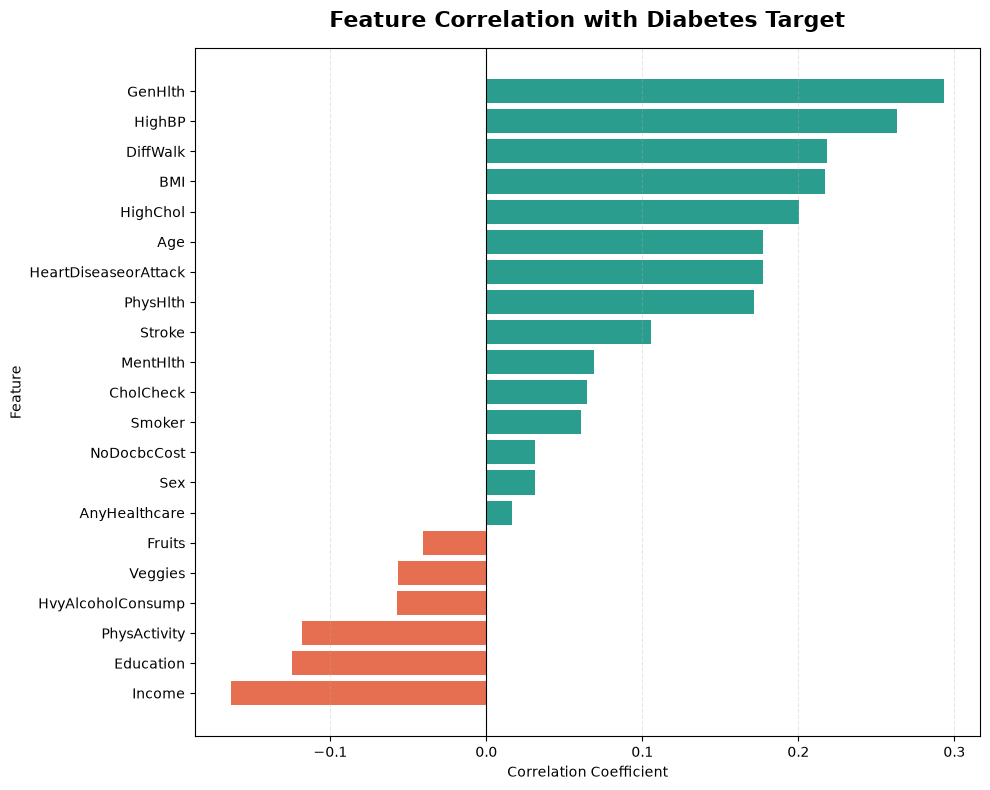

Chart saved to: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\diabetes_feature_correlations.png


In [13]:
# Calculate the linear association between each feature and the target
target_correlations = (
    df_clean
    .corr(numeric_only=True)["Diabetes_binary"]
    .drop("Diabetes_binary")
    .sort_values()
)

print("Feature correlations with the target:")
display(
    target_correlations
    .sort_values(ascending=False)
    .to_frame("Correlation")
)

# Create a horizontal correlation chart
fig, ax = plt.subplots(figsize=(10, 8))

colors = [
    "#2A9D8F" if value >= 0 else "#E76F51"
    for value in target_correlations.values
]

ax.barh(
    target_correlations.index,
    target_correlations.values,
    color=colors
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_title(
    "Feature Correlation with Diabetes Target",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Correlation Coefficient")
ax.set_ylabel("Feature")
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

# Save the chart for the final report
correlation_figure_path = (
    figures_folder
    / "diabetes_feature_correlations.png"
)

plt.savefig(
    correlation_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:", correlation_figure_path)